### 1. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UCRYGate
from qiskit import transpile
from qiskit_aer import AerSimulator

### 2. Design a simple signal

Number of samples: 32
Total duration: 4.00 ms
Sampling rate: 8000 Hz
Frequency: 700 Hz


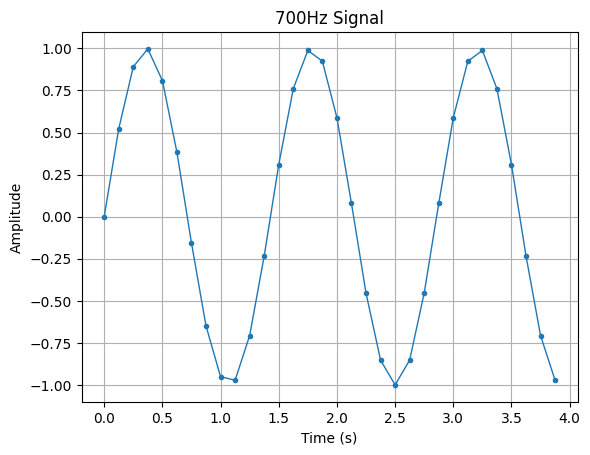

In [2]:

fs = 8000  # Sampling rate
f = 700  # Frequency of the signal in Hz
N = 32  # Number of samples

t = np.arange(N) / fs  # Time vector for N samples
signal = np.sin(2 * np.pi * f * t)  # Generate the signal

# Print number of samples, total milliseconds, sampling rate and frequency
print(f'Number of samples: {len(signal)}')
print(f'Total duration: {len(signal) / fs * 1000:.2f} ms')
print(f'Sampling rate: {fs} Hz')
print(f'Frequency: {f} Hz')

# Plot the signal
plt.plot(t * 1000, signal, marker=".", linewidth=1)
plt.title(f'{f}Hz Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

### 3. Encode signal using the EVEN scheme

In [3]:
signal = np.clip(signal, -1.0, 1.0) # Make sure the audio is inside the domain [-1, 1]

theta = np.arccos(signal) # theta_i in [0, pi]

# Print the angles in radians and angle in degrees
print("Angles (radians):", theta)
print("Angles (degrees):", np.degrees(theta))

Angles (radians): [1.57079633 1.02101761 0.4712389  0.07853982 0.62831853 1.17809725
 1.72787596 2.27765467 2.82743339 2.9059732  2.35619449 1.80641578
 1.25663706 0.70685835 0.15707963 0.39269908 0.9424778  1.49225651
 2.04203522 2.59181394 3.14159265 2.59181394 2.04203522 1.49225651
 0.9424778  0.39269908 0.15707963 0.70685835 1.25663706 1.80641578
 2.35619449 2.9059732 ]
Angles (degrees): [ 90.   58.5  27.    4.5  36.   67.5  99.  130.5 162.  166.5 135.  103.5
  72.   40.5   9.   22.5  54.   85.5 117.  148.5 180.  148.5 117.   85.5
  54.   22.5   9.   40.5  72.  103.5 135.  166.5]


### 4. Encode signal as a QCrank state using the EVEN scheme's angles

In [4]:
n_addr = int(np.log2(N)) # Number of address qubits needed
assert 2**n_addr == N, "QCrank address size requires N to be a power of two"

addr = QuantumRegister(n_addr, "addr") # address qubits
data = QuantumRegister(1, "x") # 1 audio channel

qc_qcrank = QuantumCircuit(addr, data, name="QCrank_audio")

# Uniform superposition over all address qubits using Hadamard gates
qc_qcrank.h(addr)

# Uniformly controlled Ry: for each address, apply Ry(theta[i]) to the data qubit.
# Qiskit UCRYGate convention: qubit 0 of the gate is the target, remaining qubits are controls.
qc_qcrank.append(UCRYGate(theta.tolist()), [data[0]] + list(addr))

# Measurement circuit for later reconstruction
c_addr = ClassicalRegister(n_addr, "c_addr")
c_data = ClassicalRegister(1, "c_x")

qc_meas = qc_qcrank.copy(name="QCrank_audio_measured")
qc_meas.add_register(c_addr)
qc_meas.add_register(c_data)

qc_meas.measure(addr, c_addr)
qc_meas.measure(data[0], c_data[0])

# Print circuit information
print(qc_qcrank)
print(f"Total qubits: {qc_qcrank.num_qubits}")
print(f"Address qubits: {qc_qcrank.num_qubits - 1}")  # subtract data qubit
print(f"Data qubits: 1")
print(f"Total circuit depth: {qc_qcrank.depth()}")
print(f"Total circuit operations: {qc_qcrank.count_ops()}")

qc_qcrank.decompose(reps=5).count_ops()


        ┌───┐»
addr_0: ┤ H ├»
        ├───┤»
addr_1: ┤ H ├»
        ├───┤»
addr_2: ┤ H ├»
        ├───┤»
addr_3: ┤ H ├»
        ├───┤»
addr_4: ┤ H ├»
        └───┘»
     x: ─────»
             »
«        ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
«addr_0: ┤1                                                                                                                                                                                                 ├
«        │                                                                                                                                                                                                  │
«addr_1: ┤2                                                                                                                                                                                

OrderedDict([('u', 37), ('cx', 32)])

### 5. Basis-gates circuit visualization

Basis-gate circuit
------------------
Qubits:     6
Depth:      64
Operations: 69
Gate counts: OrderedDict({'ry': 32, 'cx': 32, 'h': 5})
            ┌───┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
addr_0: ────┤ H ├──────■──────────────────────────────────────────■─────────────────────────────────────────■───────────────────────────────────────■────────────────────────────────────────■──

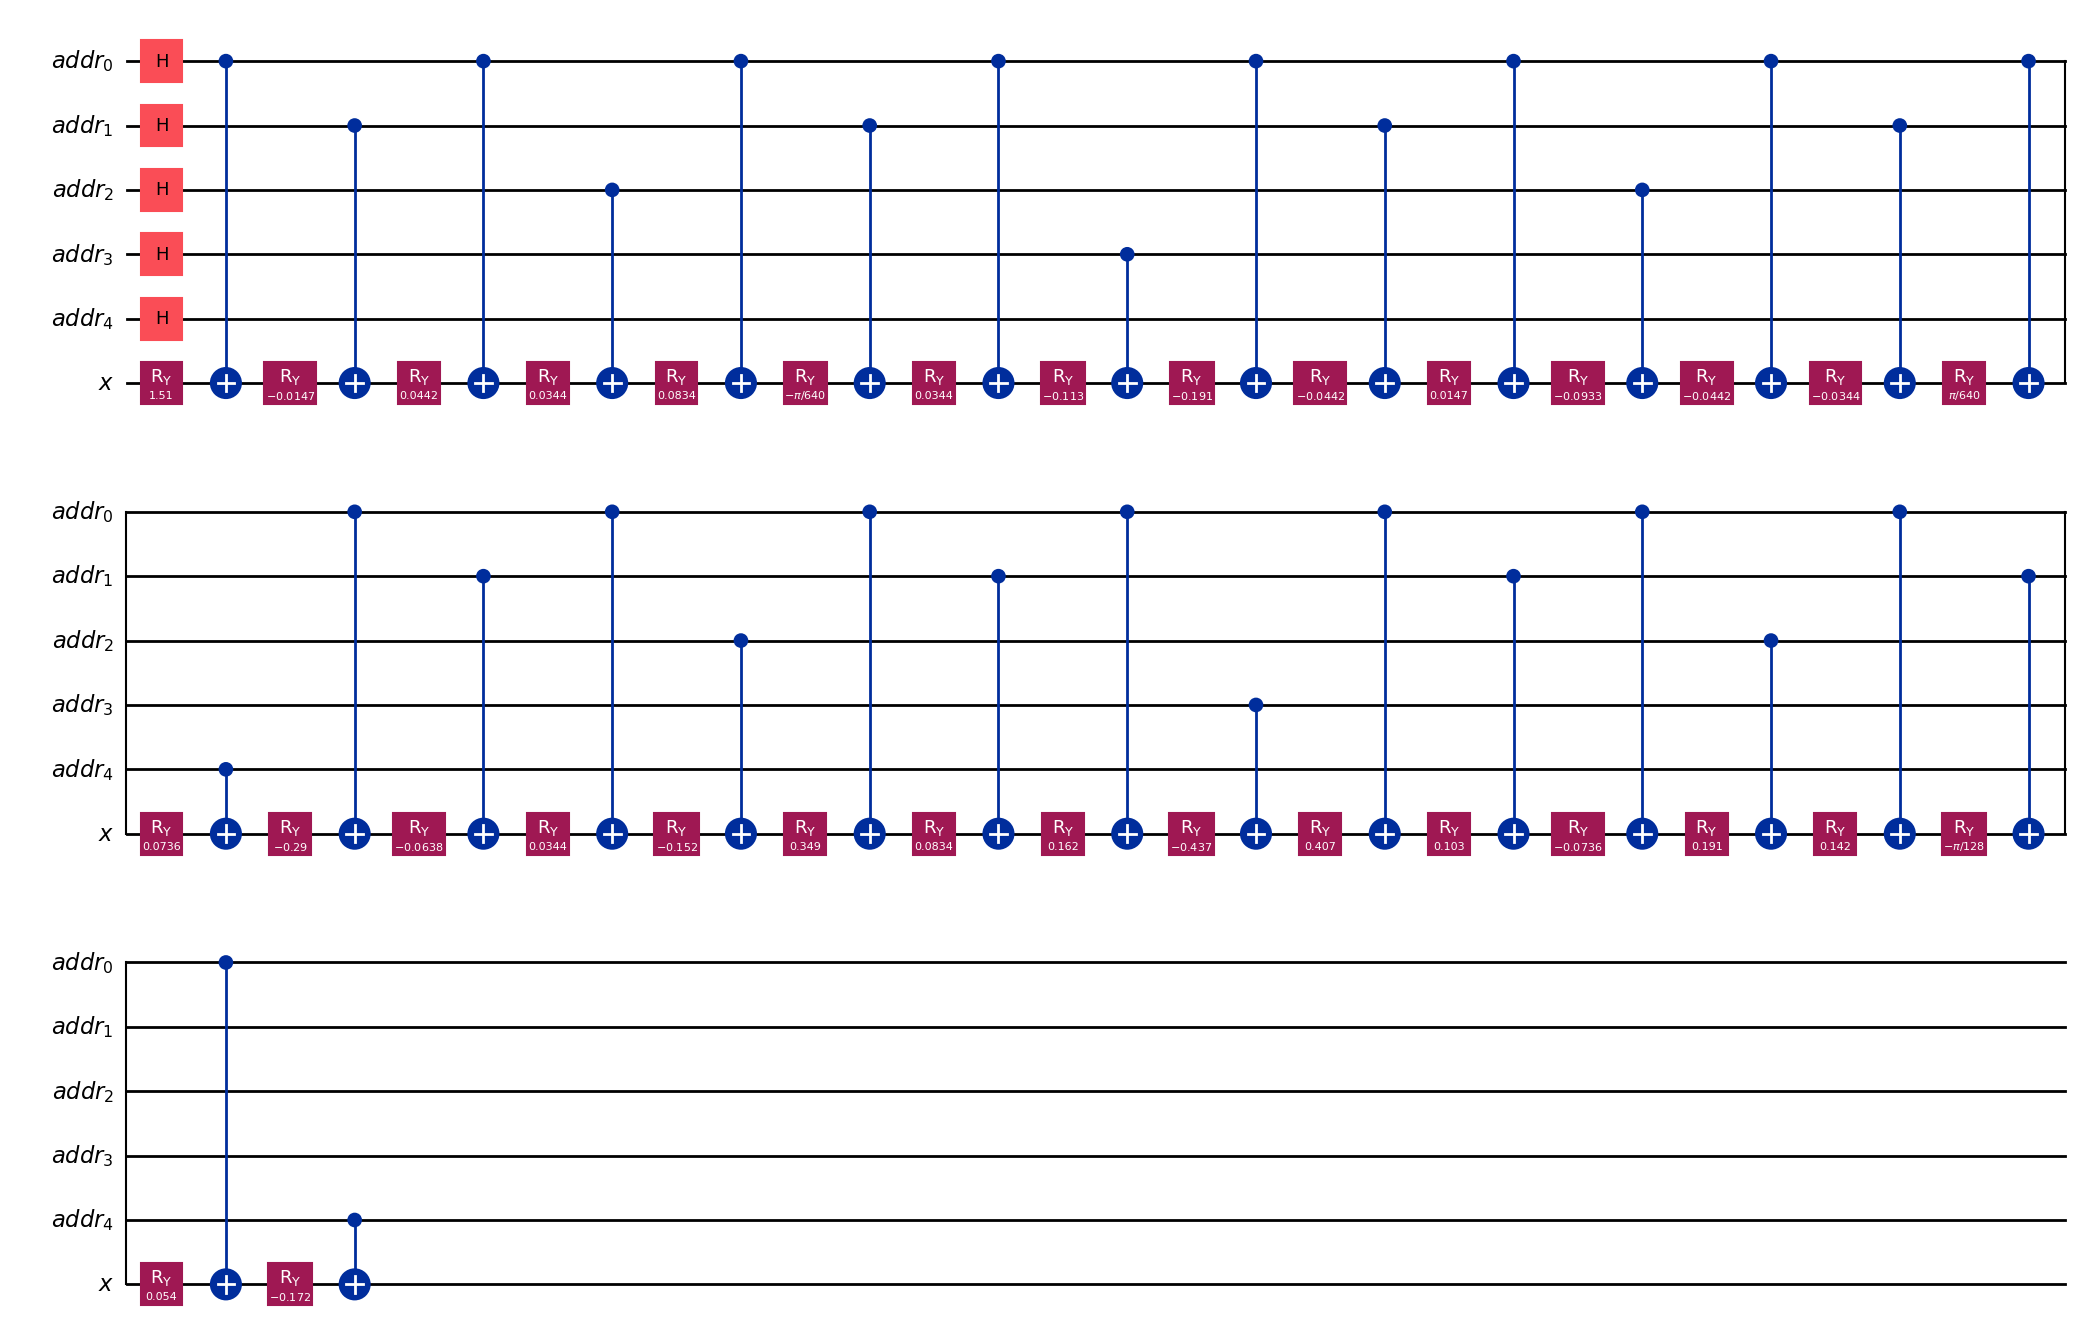


Individual basis-gate instructions
----------------------------------
0000 | H   | qubits=[0] | parameters=—
0001 | H   | qubits=[1] | parameters=—
0002 | H   | qubits=[2] | parameters=—
0003 | H   | qubits=[3] | parameters=—
0004 | H   | qubits=[4] | parameters=—
0005 | RY  | qubits=[5] | parameters=['+1.5069827260']
0006 | CX  | qubits=[0, 5] | parameters=—
0007 | RY  | qubits=[5] | parameters=['-0.0147262156']
0008 | CX  | qubits=[1, 5] | parameters=—
0009 | RY  | qubits=[5] | parameters=['+0.0441786467']
0010 | CX  | qubits=[0, 5] | parameters=—
0011 | RY  | qubits=[5] | parameters=['+0.0343611696']
0012 | CX  | qubits=[2, 5] | parameters=—
0013 | RY  | qubits=[5] | parameters=['+0.0834485549']
0014 | CX  | qubits=[0, 5] | parameters=—
0015 | RY  | qubits=[5] | parameters=['-0.0049087385']
0016 | CX  | qubits=[1, 5] | parameters=—
0017 | RY  | qubits=[5] | parameters=['+0.0343611696']
0018 | CX  | qubits=[0, 5] | parameters=—
0019 | RY  | qubits=[5] | parameters=['-0.1129009860']


In [5]:
# Decompose QCrank into individual basis gates. Qiskit UCRGate is composed by CXs and Ry gates. The angles it shown here after plotting are not the same angles I inputted because this UCRYGate performs a transformation of the angles to implement the uniformly controlled rotation.

# Basis:
#   h  : prepares the address superposition
#   ry : encodes the audio amplitudes
#   cx : implements the uniformly controlled rotation
basis_gates = ["h", "ry", "cx"]

qc_qcrank_basis = transpile(
    qc_qcrank,
    basis_gates=basis_gates,
    optimization_level=0,   # Do not combine or cancel gates
)

# Verify that no composite gates remain
remaining_gates = (
    set(qc_qcrank_basis.count_ops().keys())
    - set(basis_gates)
)

assert not remaining_gates, (
    f"Unexpected non-basis gates remain: {remaining_gates}"
)

# Circuit information

print("Basis-gate circuit")
print("------------------")
print(f"Qubits:     {qc_qcrank_basis.num_qubits}")
print(f"Depth:      {qc_qcrank_basis.depth()}")
print(f"Operations: {qc_qcrank_basis.size()}")
print(f"Gate counts: {qc_qcrank_basis.count_ops()}")


# Draw every basis-gate instance explicitly

# Text drawing
# fold=-1 places the complete circuit on one line, which may be very wide.
print(
    qc_qcrank_basis.draw(
        output="text",
        fold=-1,
    )
)

# Better visualization inside a Jupyter notebook:
display(
    qc_qcrank_basis.draw(
        output="mpl",
        fold=30,
        idle_wires=False,
    )
)

# Print every gate as a separate numbered instruction

def format_parameter(parameter):
    """Format numerical and symbolic Qiskit parameters."""
    try:
        return f"{float(parameter):+.10f}"
    except (TypeError, ValueError):
        return str(parameter)


print("\nIndividual basis-gate instructions")
print("----------------------------------")

for gate_number, instruction in enumerate(qc_qcrank_basis.data):
    operation = instruction.operation

    qubit_indices = [
        qc_qcrank_basis.find_bit(qubit).index
        for qubit in instruction.qubits
    ]

    parameters = [
        format_parameter(parameter)
        for parameter in operation.params
    ]

    print(
        f"{gate_number:04d} | "
        f"{operation.name.upper():3s} | "
        f"qubits={qubit_indices} | "
        f"parameters={parameters if parameters else '—'}"
    )

### 6. Circuit execution

In [6]:
from qiskit_aer import AerSimulator

# Copy the circuit so the original QCrank circuit is unchanged
qc_sv = qc_qcrank_basis.copy()

# Remove terminal measurements if you want the encoded quantum state
qc_sv.remove_final_measurements(inplace=True)

# Tell Aer to include the statevector in the result
qc_sv.save_statevector()

simulator = AerSimulator(method="statevector")
result = simulator.run(qc_sv).result()

statevector = result.get_statevector(qc_sv)

# Optional: convert Qiskit's Statevector object to a NumPy array
statevector_array = statevector.data

### 7. Decoding stage

In [7]:
# Decode the statevector back into audio amplitudes using the angle 
audio_amplitudes = []
for amplitude in statevector_array:
    audio_amplitudes.append(abs(amplitude) ** 2)

angles_from_amplitudes = np.arccos(np.sqrt(audio_amplitudes))
print("\nAngles from Audio Amplitudes")
print("-----------------------------")
for index, amplitude in enumerate(angles_from_amplitudes):
    print(f"Index {index:02d}: {amplitude:.10f}")


Angles from Audio Amplitudes
-----------------------------
Index 00: 1.4454684956
Index 01: 1.4159412005
Index 02: 1.3980460455
Index 03: 1.3932241934
Index 04: 1.4018694195
Index 05: 1.4232774114
Index 06: 1.4557353323
Index 07: 1.4967193121
Index 08: 1.5431388331
Index 09: 1.5500169588
Index 10: 1.5030951085
Index 11: 1.4611352875
Index 12: 1.4272889087
Index 13: 1.4041760718
Index 14: 1.3936393617
Index 15: 1.3965357294
Index 16: 1.4126284798
Index 17: 1.4406178549
Index 18: 1.4782989159
Index 19: 1.5227935480
Index 20: 1.5707963268
Index 21: 1.5227935480
Index 22: 1.4782989159
Index 23: 1.4406178549
Index 24: 1.4126284798
Index 25: 1.3965357294
Index 26: 1.3936393617
Index 27: 1.4041760718
Index 28: 1.4272889087
Index 29: 1.4611352875
Index 30: 1.5030951085
Index 31: 1.5500169588
Index 32: 1.4454684956
Index 33: 1.4843117072
Index 34: 1.5295169045
Index 35: 1.5638560506
Index 36: 1.5161421184
Index 37: 1.4724258828
Index 38: 1.4359661271
Index 39: 1.4095600719
Index 40: 1.39529652